Model Accuracy: 94.74%
Predicted Class for the new sample: ['Benign']


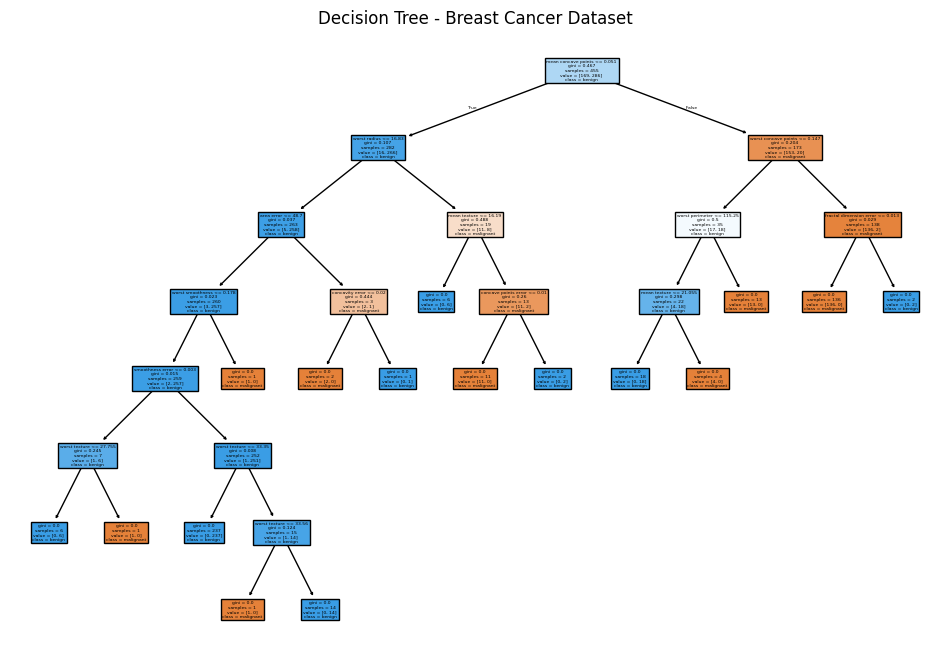

In [ ]:
# Importing necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn import tree

data = load_breast_cancer()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)* 100
print(f"Model Accuracy: {accuracy :.2f}%")
new_sample = np.array([X_test[0]])
prediction = clf.predict(new_sample)

prediction_class = ["Benign" if prediction == 1 else "Malignant"]
print(f"Predicted Class for the new sample: {prediction_class}")

plt.figure(figsize=(12,8))
tree.plot_tree(clf, filled=True, feature_names=data.feature_names, class_names=data.target_names)
plt.title("Decision Tree - Breast Cancer Dataset")
plt.show()

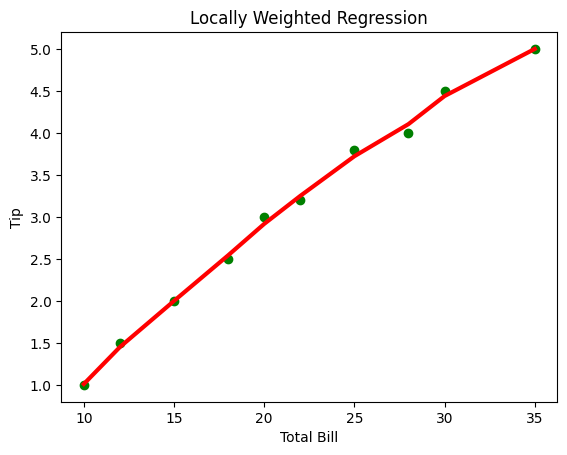

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Create sample dataset
data = pd.DataFrame({
    "total_bill": [10,12,15,18,20,22,25,28,30,35],
    "tip": [1,1.5,2,2.5,3,3.2,3.8,4,4.5,5]
})

# Input and output
x = np.array(data.total_bill)
y = np.array(data.tip)

# Add bias term
X = np.column_stack((np.ones(len(x)), x))

# Bandwidth
k = 2

# Store predictions
ypred = np.zeros(len(x))

# Locally Weighted Regression
for i in range(len(x)):

    weights = np.eye(len(x))

    for j in range(len(x)):
        diff = x[i] - x[j]
        weights[j][j] = np.exp(-(diff**2) / (2 * k**2))

    # Theta calculation
    a = X.T @ weights @ X
    b = X.T @ weights @ y

    theta = np.linalg.inv(a) @ b

    # Prediction
    ypred[i] = theta[0] + theta[1] * x[i]

# Sort for smooth graph
sort = x.argsort()

# Plot graph
plt.scatter(x, y, color="green")
plt.plot(x[sort], ypred[sort], color="red", linewidth=3)

plt.xlabel("Total Bill")
plt.ylabel("Tip")
plt.title("Locally Weighted Regression")

plt.show()

In [ ]:
import pandas as pd 
import numpy as np 
 
# Load data 
data = pd.read_csv('Training_examples.csv') 
concepts = np.array(data)[:, :-1]  # Extract features 
 
target = np.array(data)[:, -1]  # Extract target labels 
 
def train(con, tar): 
    specific_h = None  # Initialize specific hypothesis 
     
    # Find the first positive example to initialize specific_h 
    for i, val in enumerate(tar): 
        if val == 'Yes': 
            specific_h = con[i].copy() 
            break 
     
    if specific_h is None: 
        return "No positive example found." 
     
    # Generalize specific_h by iterating over the remaining examples 
    for i, val in enumerate(con): 
        if tar[i] == 'Yes': 
            for x in range(len(specific_h)): 
                if val[x] != specific_h[x]: 
                    specific_h[x] = '?' 
     
    return specific_h 
# Print the final specific hypothesis 
print(train(concepts, target)) 

FileNotFoundError: [Errno 2] No such file or directory: 'Training_examples.csv'

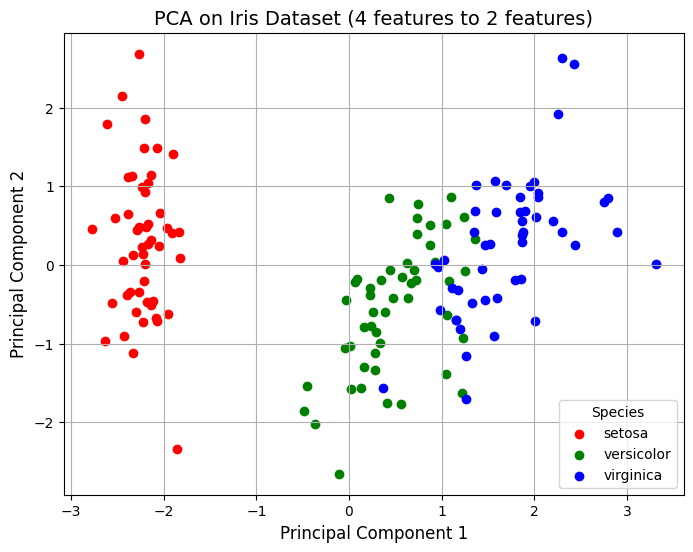

Explained Variance by each Principal Component:
Principal Component 1:  0.7296244541329989
Principal Component 2:  0.22850761786701768
Total Variance Retained:  0.9581320720000166


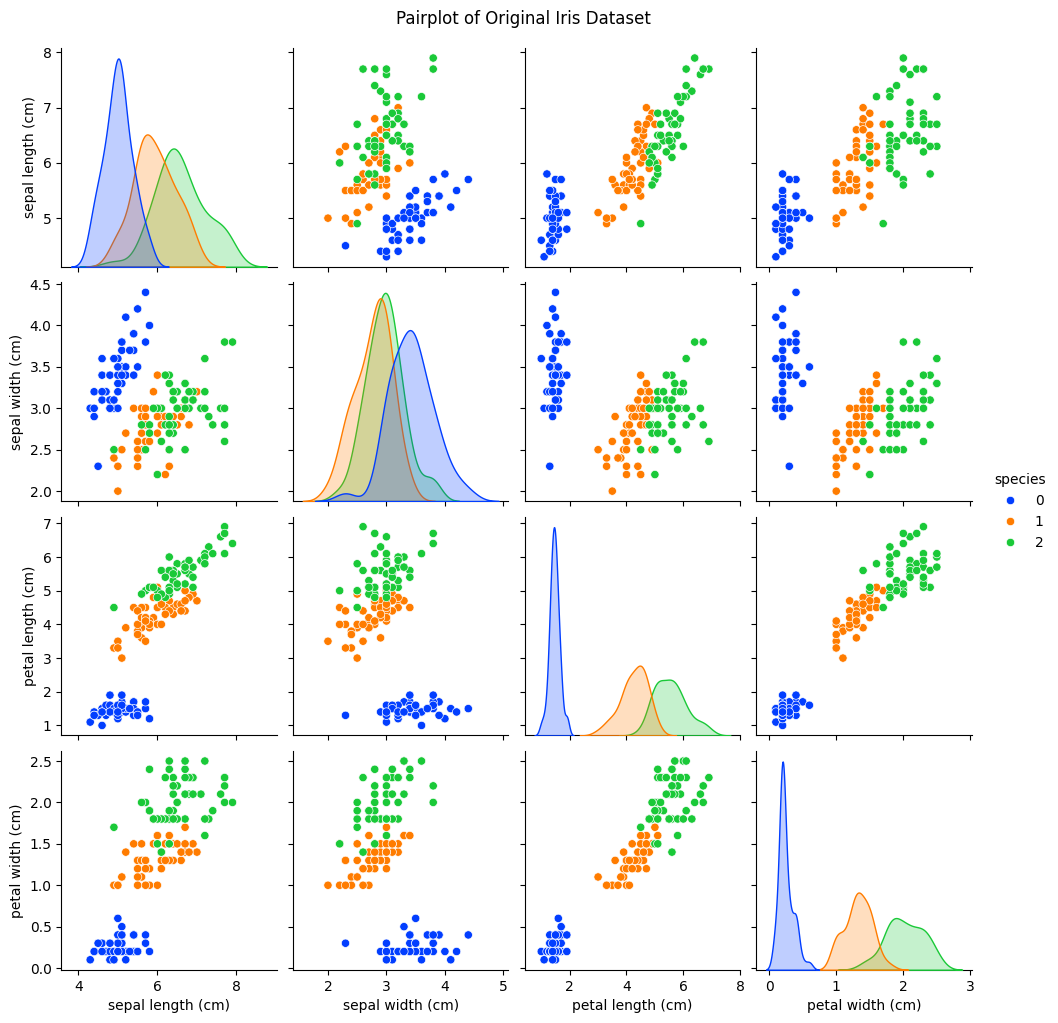

In [8]:
from sklearn.datasets import load_iris 
from sklearn.decomposition import PCA 
from sklearn.preprocessing import StandardScaler 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
# Step 1: Load the Iris dataset 
iris = load_iris() 
features = iris.data  # The 4 features: Sepal Length, Sepal Width, Petal Length, Petal Width 
target = iris.target  # The target class (species) 
# Step 2: Standardize the features 
scaler = StandardScaler() 
features_standardized = scaler.fit_transform(features) 
# Step 3: Apply PCA to reduce to 2 components 
pca = PCA(n_components=2) 
features_pca = pca.fit_transform(features_standardized) 
# Step 4: Create a DataFrame for the reduced data 
pca_df = pd.DataFrame(data=features_pca, columns=["Principal Component 1", "Principal Component 2"]) 
pca_df["Target"] = target 
# Step 5: Visualize the PCA results 
plt.figure(figsize=(8, 6)) 
plt.scatter(
    pca_df[pca_df["Target"] == 0]["Principal Component 1"],
    pca_df[pca_df["Target"] == 0]["Principal Component 2"],
    color="red", label="setosa"
)

# versicolor
plt.scatter(
    pca_df[pca_df["Target"] == 1]["Principal Component 1"],
    pca_df[pca_df["Target"] == 1]["Principal Component 2"],
    color="green", label="versicolor"
)

# virginica
plt.scatter(
    pca_df[pca_df["Target"] == 2]["Principal Component 1"],
    pca_df[pca_df["Target"] == 2]["Principal Component 2"],
    color="blue", label="virginica"
)
plt.title("PCA on Iris Dataset (4 features to 2 features)", fontsize=14) 
plt.xlabel("Principal Component 1", fontsize=12) 
plt.ylabel("Principal Component 2", fontsize=12) 
plt.legend(title="Species") 
plt.grid() 
plt.show() 
explained_variance = pca.explained_variance_ratio_ 
print("Explained Variance by each Principal Component:") 
print("Principal Component 1: ", explained_variance[0]) 
print("Principal Component 2: ", explained_variance[1]) 
print("Total Variance Retained: ", sum(explained_variance)) 
# Pairplot visualization of the original Iris dataset 
iris_df = pd.DataFrame(data=iris.data, columns=iris.feature_names) 
iris_df['species'] = iris.target 
sns.pairplot(data=iris_df, hue='species', palette='bright') 
plt.suptitle("Pairplot of Original Iris Dataset", y=1.02) 
plt.show()

In [10]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.model_selection import train_test_split 
from sklearn.neighbors import KNeighborsClassifier 
from sklearn.metrics import accuracy_score 
import warnings 
warnings.filterwarnings('ignore') 
# Step 1: Generate dataset 
np.random.seed(42) 
values = np.random.rand(100) 
labels = [] 
for i in values[:50]: 
    if i <=0.5: 
        labels.append('Class1') 
    else: 
        labels.append('Class2') 
labels += [None] * 50 
print(labels) 
data = { 
"Point": [f"x{i+1}" for i in range(100)], 
"Value": values, 
"Label": labels 
} 
df = pd.DataFrame(data) 
df.head() 
# Split data into labeled and unlabeled 
labeled_df = df[df["Label"].notna()] 
X_train = labeled_df[["Value"]] 
y_train = labeled_df["Label"] 
unlabeled_df = df[df["Label"].isna()] 
X_test = unlabeled_df[["Value"]] 
# Generate true labels for testing (for accuracy calculation) 
true_labels = ["Class1" if x <= 0.5 else "Class2" for x in values[50:]] 
# Step 2: Perform KNN classification for different values of k 
k_values = [1, 2, 3, 4, 5, 20, 30] 
results = {} 
accuracies = {} 
for k in k_values: 
    knn = KNeighborsClassifier(n_neighbors=k) 
    knn.fit(X_train, y_train) 
    predictions = knn.predict(X_test) 
    results[k] = predictions 
# Calculate accuracy 
    accuracy = accuracy_score(true_labels, predictions) * 100 
    accuracies[k] = accuracy 
    print(f"Accuracy for k={k}: {accuracy:.2f}%") 

print(predictions) 

['Class1', 'Class2', 'Class2', 'Class2', 'Class1', 'Class1', 'Class1', 'Class2', 'Class2', 'Class2', 'Class1', 'Class2', 'Class2', 'Class1', 'Class1', 'Class1', 'Class1', 'Class2', 'Class1', 'Class1', 'Class2', 'Class1', 'Class1', 'Class1', 'Class1', 'Class2', 'Class1', 'Class2', 'Class2', 'Class1', 'Class2', 'Class1', 'Class1', 'Class2', 'Class2', 'Class2', 'Class1', 'Class1', 'Class2', 'Class1', 'Class1', 'Class1', 'Class1', 'Class2', 'Class1', 'Class2', 'Class1', 'Class2', 'Class2', 'Class1', None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None]
Accuracy for k=1: 100.00%
Accuracy for k=2: 100.00%
Accuracy for k=3: 98.00%
Accuracy for k=4: 98.00%
Accuracy for k=5: 98.00%
Accuracy for k=20: 98.00%
Accuracy for k=30: 100.00%
['Class2' 'Class2' 

In [ ]:
import pandas as pd
import numpy as np

data=pd.read_csv('Training.csv')
concepts=np.array(data)[:,:-1]
target=np.array(data)[:,-1]

def train(con,tar):
    specific_h=None

    for i,val in enumerate(tar):
        if val=='Yes':
            specific_h=con[i].copy()
            break


    if specific_h is None:
        return "No positive example found"
    

    for i,val in enumerate(con):

        if(tar[i]=='Yes'):

            for x in range(len(specific_h)):
                if val[x]!=specific_h[x]:
                    specific_h[x]='?'
    return specific_h
print(train(concepts,target))

       MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0      8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1      8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2      7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3      5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4      3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   
...       ...       ...       ...        ...         ...       ...       ...   
20635  1.5603      25.0  5.045455   1.133333       845.0  2.560606     39.48   
20636  2.5568      18.0  6.114035   1.315789       356.0  3.122807     39.49   
20637  1.7000      17.0  5.205543   1.120092      1007.0  2.325635     39.43   
20638  1.8672      18.0  5.329513   1.171920       741.0  2.123209     39.43   
20639  2.3886      16.0  5.254717   1.162264      1387.0  2.616981     39.37   

       Longitude  MedHouseVal  
0      

<Figure size 1200x800 with 0 Axes>

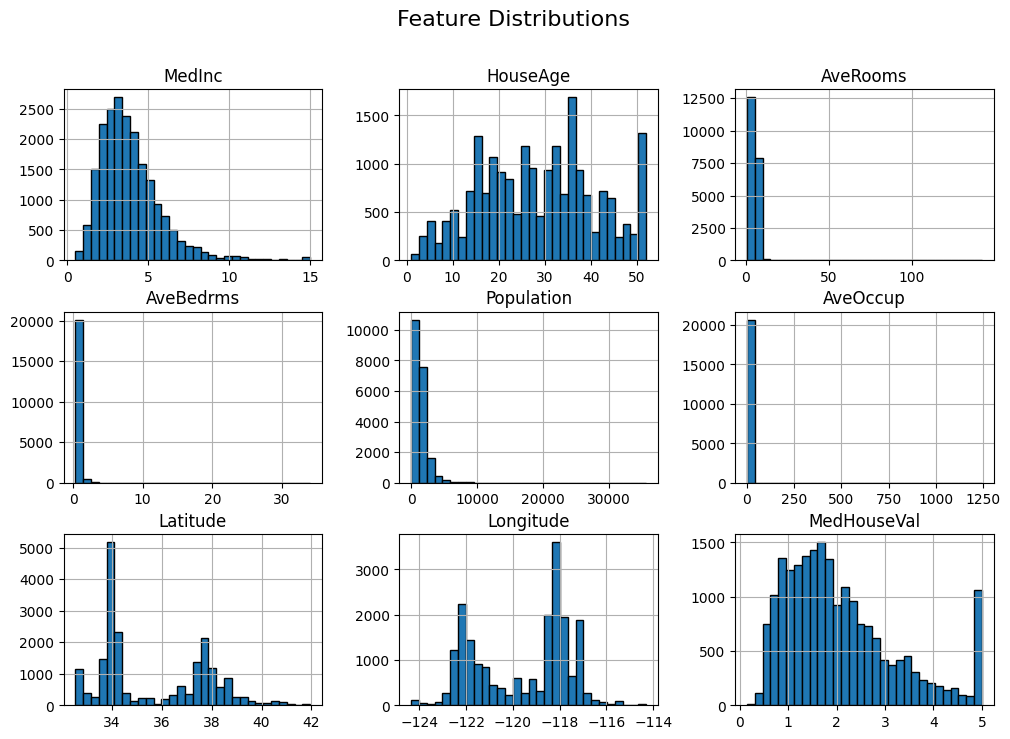

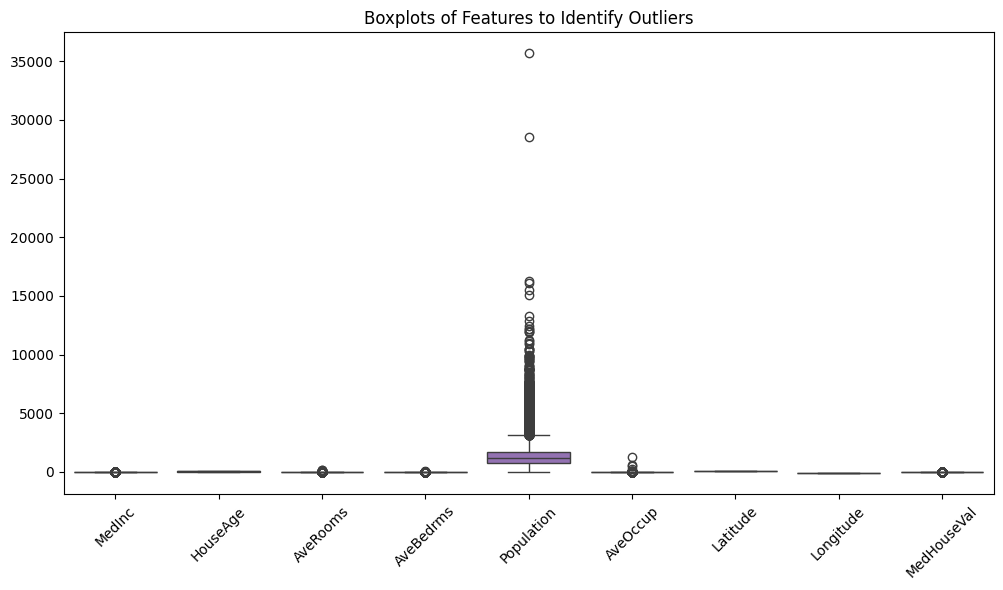

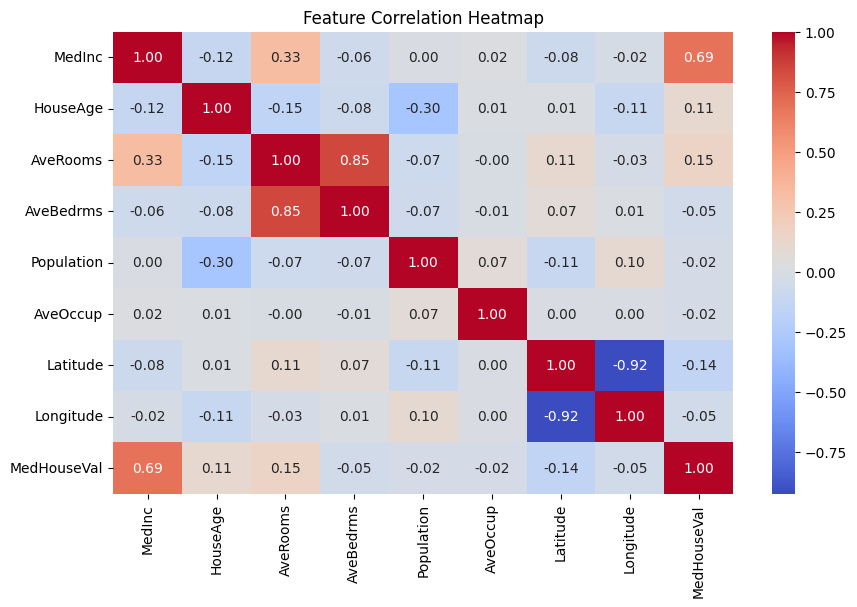

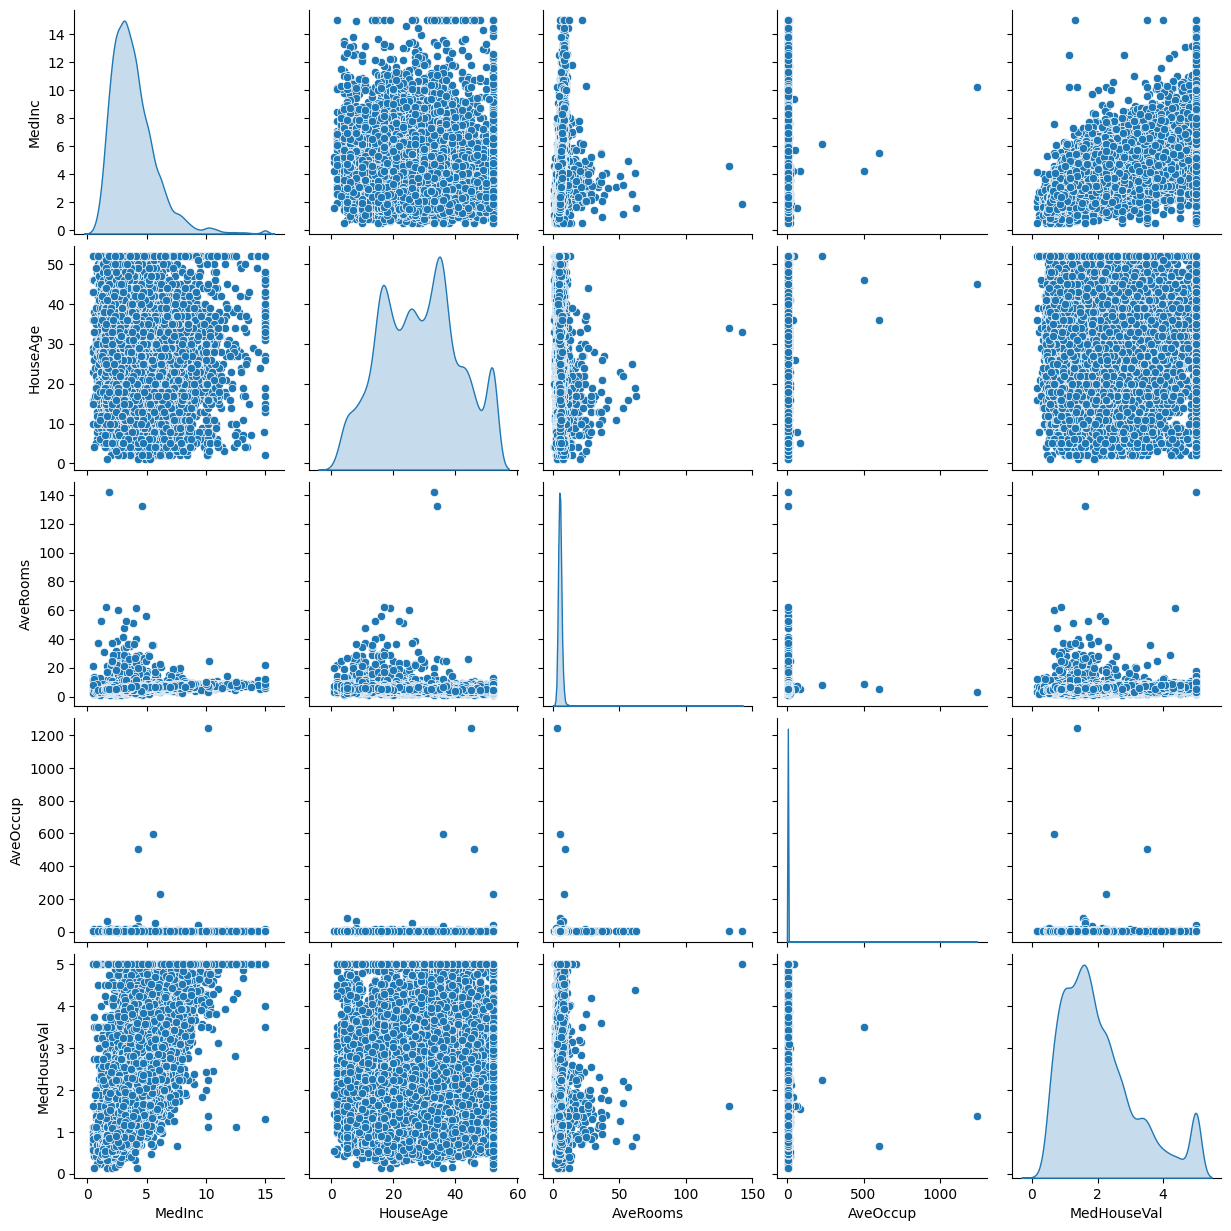

In [11]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.datasets import fetch_california_housing 
#Load California Housing dataset 
df = fetch_california_housing(as_frame=True).frame  
print(df) 
print("\nBasic Information about Dataset:") 
print(df.info())  # Overview of dataset 
print("\nFirst Five Rows of Dataset:") 
print(df.head())  # Display first few rows 
print("\nSummary Statistics:") 
print(df.describe())  # Summary statistics of dataset 
print("\nMissing Values in Each Column:") 
print(df.isnull().sum())  # Count of missing values 
plt.figure(figsize=(12, 8)) 
df.hist(figsize=(12, 8), bins=30, edgecolor='black') 
plt.suptitle("Feature Distributions", fontsize=16) 
plt.show() 
plt.figure(figsize=(12, 6)) 
sns.boxplot(data=df) 
plt.xticks(rotation=45) 
plt.title("Boxplots of Features to Identify Outliers") 
plt.show() 
plt.figure(figsize=(10, 6)) 
corr_matrix = df.corr() 
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f') 
plt.title("Feature Correlation Heatmap") 
plt.show() 
sns.pairplot(df[['MedInc', 'HouseAge', 'AveRooms', 'AveOccup', 'MedHouseVal']], 
diag_kind="kde")  
plt.show()

Accuracy is | 94.74%
Prediction class is : ['Benign']


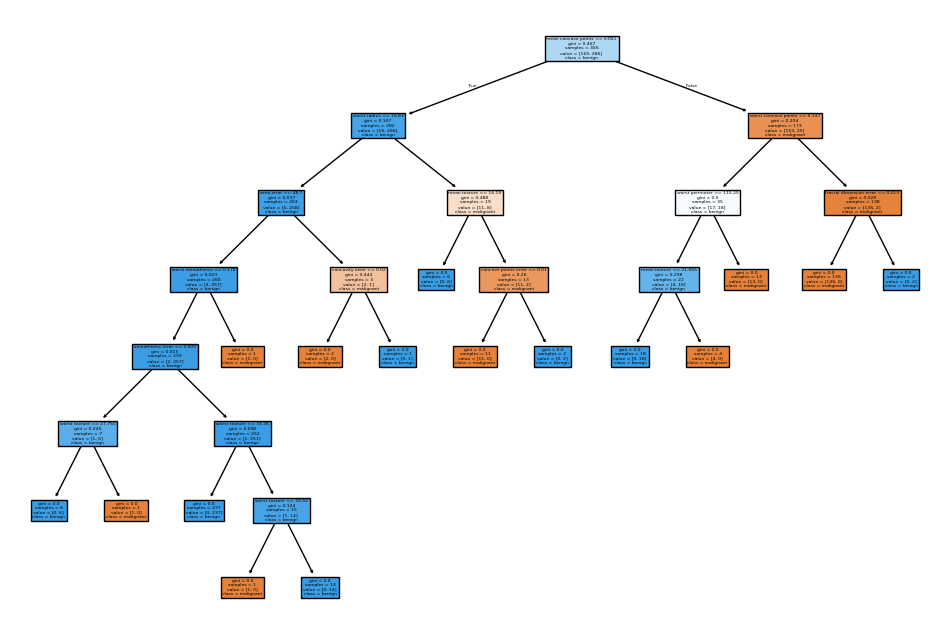

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import accuracy_score

from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn import tree
from sklearn.model_selection import train_test_split
data=load_breast_cancer()
X=data.data
y=data.target

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

model=DecisionTreeClassifier(random_state=42)
model.fit(X_train,y_train)
y_pred=model.predict(X_test)

accuracy=accuracy_score(y_test,y_pred)*100
print(f"Accuracy is | {accuracy:.2f}%")

new_sample=np.array([X_test[1]])
prediction=model.predict(new_sample)

prediction_class=["Malignant" if prediction==1 else "Benign"]
print(f"Prediction class is : {prediction_class}")

plt.figure(figsize=(12,8))
plt.title("Decision tree Representation")
tree.plot_tree(model,filled=True,feature_names=data.feature_names,class_names=data.target_names)
plt.show()

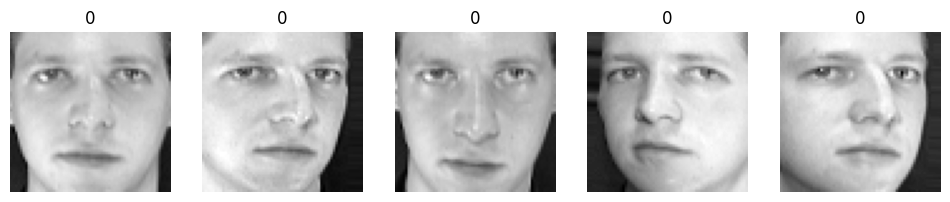

Accuracy is given by  0.8375
Classification is given by                precision    recall  f1-score   support

           0       0.75      1.00      0.86         3
           1       1.00      1.00      1.00         1
           2       1.00      1.00      1.00         2
           3       1.00      1.00      1.00         4
           4       1.00      0.67      0.80         3
           5       1.00      1.00      1.00         3
           7       0.00      0.00      0.00         6
           8       1.00      1.00      1.00         2
           9       0.29      1.00      0.44         2
          10       1.00      0.50      0.67         2
          11       1.00      0.67      0.80         3
          12       0.50      0.50      0.50         2
          13       1.00      1.00      1.00         1
          14       1.00      1.00      1.00         3
          15       0.50      1.00      0.67         2
          16       0.00      0.00      0.00         0
          17       1.00 

C:\Users\Akash kulkarni\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Akash kulkarni\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Akash kulkarni\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sk

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_olivetti_faces
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB

data=fetch_olivetti_faces()
images=data.images
targets=data.target

plt.figure(figsize=(12,8))
for i in range(5):
    plt.subplot(2,5,i+1)
    plt.imshow(images[i],cmap='gray')
    plt.title(targets[i])
    plt.axis('off')
plt.show()

X=images.reshape(400,4096)
y=targets

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

model=GaussianNB()
model.fit(X_train,y_train)
ypred=model.predict(X_test)

accuracy=accuracy_score(y_test,ypred)
print("Accuracy is given by ",accuracy)

print("Classification is given by ",classification_report(y_test,ypred))

comparison=pd.DataFrame({
    "Actual": y_test,
    "Predicted":ypred
})
comparison["Match"]=comparison["Actual"]==comparison["Predicted"]
print("\nFirst 20 sample faces are\n")
print(comparison.head(20))

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
data=pd.read_csv("tips.csv")
x=np.array(data.total_bill)
y=np.array(data.tip)

X=np.column_stack((np.ones(len(x))),x)
k=2
y_pred=np.zeros(len(x))
for i in range(len(x)):
    weights=np.eye(len(x))

    for j in range(len(x)):
        diff=x[i]-x[j]
        weights[j][j]=np.exp(-(diff**2) / (2*k**2))

    theta=np.linalg.inv(X.T @ weights @ X) @ (X.T @ weights @ y)
    y_pred[i]=[1,x[i]] @ theta
sort=x.argsort()

plt.scatter(x,y,color='red')
plt.plot(x[sort],y[sort],color='green',linewidth=4)
plt.xlabel('total_bill')
plt.ylabel('tip')
plt.title('Locally weighted regreesion')
plt.show()


In [ ]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.cluster import KMeans 
from sklearn.preprocessing import StandardScaler 
from sklearn.decomposition import PCA 
from sklearn.metrics import silhouette_score 
from sklearn.datasets import load_breast_cancer
import warnings 
warnings.filterwarnings('ignore') 
data = load_breast_cancer()


X=data.data

scaler = StandardScaler() 
X_scaled = scaler.fit_transform(X) 
# Apply PCA for Dimensionality Reduction 
pca = PCA(n_components=2) # Reduce to 2 dimensions for visualization 
X_pca = pca.fit_transform(X_scaled) 
# Check explained variance ratio 
explained_variance = pca.explained_variance_ratio_ 
total_explained_variance = np.sum(explained_variance) 
print(f"Variance explained by PC1: {explained_variance[0]:.4f}") 
print(f"Variance explained by PC2: {explained_variance[1]:.4f}") 
#Apply K-Means Clustering with the optimal k (usually where elbow occurs, k=2) 
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10) 
clusters = kmeans.fit_predict(X_pca) 
# Step 7: Visualize the Clusters 
plt.figure(figsize=(8, 6)) 
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap="viridis", alpha=0.6) 
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=200) 
plt.xlabel("Principal Component 1") 
plt.ylabel("Principal Component 2") 
plt.title("K-Means Clustering after PCA")

AttributeError: 'numpy.ndarray' object has no attribute 'columns'